<a href="https://colab.research.google.com/github/JanviThawani/Bitcoin-price-prediction/blob/main/Bitcoin_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'IMG_20230413_143538.jpg', 'IMG_20230413_143623.jpg', 'IMG_20231020_203433.jpg', 'Janvithawani_23fs10bca00062.pdf', 'SAVE_20240228_180604.pdf', 'CBSE - Senior School Certificate Examination (Class XII) Results 2023.pdf', 'janvi jb ppt.pdf', 'DOC-20241004-WA0068..pdf', 'DOC-20231213-WA0021..pdf', '29689b76-1ede-4551-b3b5-3890d6eda935.JPG', 'certificate_Janvi .pdf', 'Saved from the Google app', 'Coursera WL1INFFWBPRI.pdf', 'final janvi resume.pdf', 'Janvi Resume (5).pdf', 'Janvi Resume (4).pdf', 'Janvi Resume (3).pdf', 'Janvi Resume (2).pdf', 'Janvi Resume (1).pdf', 'Janvi Resume.pdf', 'Netflix movie data analysis_explanation', 'Document.rtf', 'Document1.rtf', 'Document2.rtf', 'Janvi pp', 'Janvi Resume Updated', '7dc3b350-4f35-40c0-bc74-b5ff10a3aeff.jpeg', '86235e1b-e2fe-47e6-a1c4-c08502be4a3a.jpeg', 'Colab Notebooks', '23fs10bca00062_cloud.pdf', 'Introduction to Internet of Things.pdf', '54fae967-df54-43ed-bef5-26f683738e8f.JPG', 'Resume.pdf', 'Resume_JanviThawani (3).pdf'

In [117]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
df = pd.read_csv('/content/drive/MyDrive/bitcoin project/btc-usd-max.csv')
df.head()

,snapped_at,price,market_cap,total_volume
0,2013-04-28 00:00:00 UTC,135.30,1.500518e+09,0.0
1,2013-04-29 00:00:00 UTC,141.96,1.575032e+09,0.0
2,2013-04-30 00:00:00 UTC,135.30,1.501657e+09,0.0
3,2013-05-01 00:00:00 UTC,117.00,1.298952e+09,0.0
4,2013-05-02 00:00:00 UTC,103.43,1.148668e+09,0.0


In [118]:
df['price_log'] = np.log(df['price'])

In [119]:
df.columns

Index(['snapped_at', 'price', 'market_cap', 'total_volume', 'price_log'], dtype='object')

In [120]:
features = [
    'return', 'ma7', 'ma14', 'volatility', 'rsi',
    'ema', 'momentum', 'vol_change',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7'
]

In [121]:
def add_crypto_features(df):
    df = df.copy()

    # Date
    df['Date'] = pd.to_datetime(df['snapped_at'])
    df = df.sort_values('Date')

    # Log price
    df['price_log'] = np.log(df['price'])

    # Target
    df['target'] = df['price_log'].shift(-1)

    # Returns
    df['return'] = df['price_log'].diff()

    # Moving averages
    df['ma7'] = df['price_log'].rolling(7).mean()
    df['ma14'] = df['price_log'].rolling(14).mean()

    # Volatility
    df['volatility'] = df['price_log'].rolling(7).std()
    df['ema'] = df['price_log'].ewm(span=10).mean()
    df['momentum'] = df['price_log'] - df['price_log'].shift(5)
    df['vol_change'] = df['total_volume'].pct_change()
    df['trend'] = np.arange(len(df))
    # RSI
    delta = df['price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

    # Lag features
    for i in range(1, 8):
        df[f'lag_{i}'] = df['price_log'].shift(i)

    # Final clean
    return df.dropna()

In [122]:
df = add_crypto_features(df)

In [123]:
print(df.columns)

Index(['snapped_at', 'price', 'market_cap', 'total_volume', 'price_log',
       'Date', 'target', 'return', 'ma7', 'ma14', 'volatility', 'ema',
       'momentum', 'vol_change', 'trend', 'rsi', 'lag_1', 'lag_2', 'lag_3',
       'lag_4', 'lag_5', 'lag_6', 'lag_7'],
      dtype='object')


In [124]:
X = df[features]
y = df['target']

In [125]:
df['price_change'] = df['price_log'].diff()
df = df.dropna()

X = df[features]
y = df['target']

In [126]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [128]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [129]:
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)
from sklearn.linear_model import Ridge

lr = Ridge(alpha=1.0)
lr.fit(X_train, y_train)

y_pred_xgb = model.predict(X_test)
y_pred_lr = lr.predict(X_test)

# Combine predictions
y_pred = 0.6 * y_pred_xgb + 0.4 * y_pred_lr

In [130]:
actual_price = np.exp(y_test)
predicted_price = np.exp(y_pred)

In [131]:
y_pred_xgb = model.predict(X_test)

# Combine predictions
y_pred = 0.7 * y_pred_xgb + 0.3 * y_pred_lr

In [132]:
actual_price = np.exp(y_test)
predicted_price = np.exp(y_pred)

In [133]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
r2 = r2_score(actual_price, predicted_price)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 21327.22472412404
R2: 0.35717018549351276


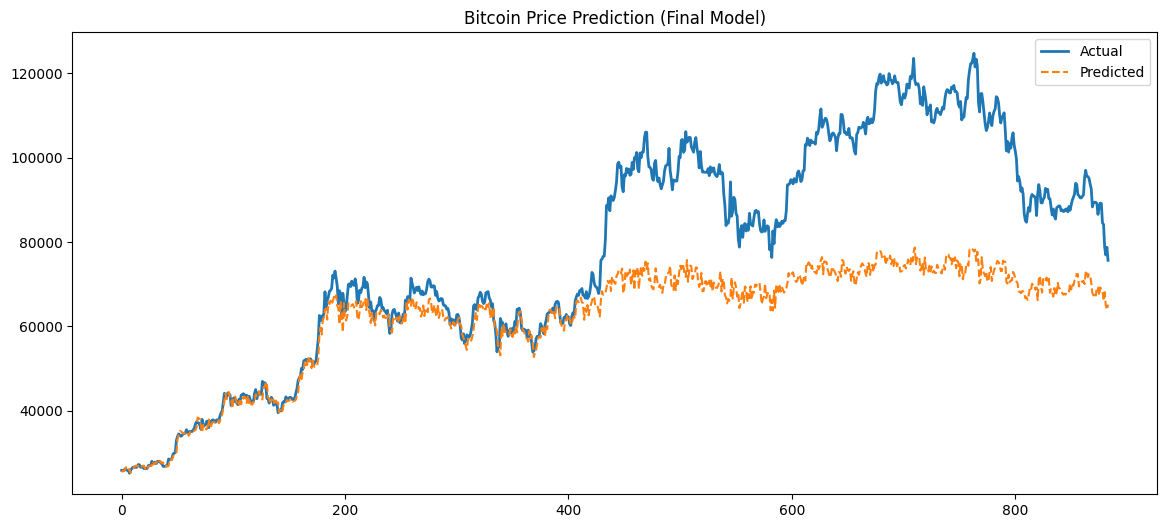

In [134]:
plt.figure(figsize=(14,6))

plt.plot(range(len(actual_price)), actual_price, label='Actual', linewidth=2)
plt.plot(range(len(actual_price)-len(predicted_price), len(actual_price)),
         predicted_price, label='Predicted', linestyle='--')

plt.legend()
plt.title("Bitcoin Price Prediction (Final Model)")
plt.show()

In [135]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6379471360750217
